In [1]:
import xarray as xr
import dask.array as da
from dask.distributed import LocalCluster, Client, performance_report
import numpy as np
import psutil
import os
from dask.diagnostics import ProgressBar

# Auto-configure based on available cores
total_cores = psutil.cpu_count(logical=True)
n_workers = max(1, total_cores // 2)  # Conservative split
threads_per_worker = max(1, total_cores // n_workers)

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    worker_dashboard_address=False,
    diagnostics_port=None  # Disable per-worker dashboards
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 16,Total memory: 98.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41659,Workers: 8
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 98.23 GiB
Comm: tcp://127.0.0.1:33839,Total threads: 2
Dashboard: http://127.0.0.1:33197/status,Memory: 12.28 GiB
Nanny: tcp://127.0.0.1:35527,


In [2]:
stac_item = "https://stac.intertwin.fedcloud.eu/collections/EMO1_DEM"

from openeo.local import LocalConnection
local_conn = LocalConnection("./")

spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

dem = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
    bands=["dem"]
).execute()
dem = dem.to_dataset(dim='bands')["dem"].to_dataset()
dem = dem.isel(time=0)
dem = dem.drop_vars("time").rename({'lat': 'y', 'lon': 'x'})
dem = dem.sortby("y")
dem_cleaned = dem.where(dem >= 0)
land_sea_mask = xr.where(dem_cleaned.notnull(), 1, 0)
land_sea_mask = land_sea_mask.rename({"dem": "land_sea_mask"})
land_sea_mask = land_sea_mask.land_sea_mask.compute()
land_sea_mask

<xarray.DataArray 'land_sea_mask' (y: 540, x: 720)> Size: 3MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])
Coordinates:
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.97 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99

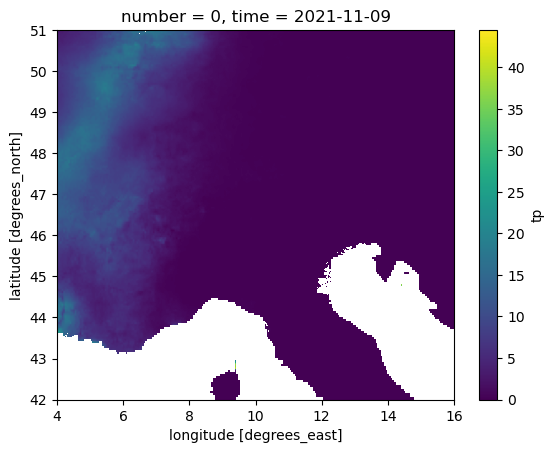

In [3]:
import xarray as xr
from pathlib import Path
import pyet


def remove_sea_areas(main_ds, mask_ds):
    """
    Remove sea areas by setting them to NaN, keeping only land areas.
    Assumes mask has 1 for land and 0 for sea.
    
    Args:
        main_ds: xarray Dataset with variables to mask
        mask_ds: xarray Dataset with land-sea mask (1=land, 0=sea)
    
    Returns:
        Masked xarray Dataset
    """
    # Ensure mask is properly aligned with main dataset
    mask_aligned = mask_ds.reindex_like(main_ds, method='nearest')
    
    # Create land mask (True for land, False for sea)
    land_mask = mask_aligned == 1
    
    # Apply mask to each variable in the dataset
    masked_ds = main_ds.copy()
    for var in masked_ds.data_vars:
        masked_ds[var] = masked_ds[var].where(land_mask)
    
    return masked_ds

# Define base directories for each variable
base_paths = {
    "t2m": Path("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/t2m_v3"),
    "tp": Path("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/tp_v3_1/tp"),
    "ssrd": Path("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ssrd_v3_1/ssrd")
}

# Get all month_year combinations from one of the folders
month_years = sorted([
    f.name.split("_seas5_")[1].replace(".zarr", "")
    for f in base_paths["t2m"].glob("t2m_seas5_*.zarr")
])

# Store combined datasets here
combined_datasets = {}

for my in month_years:
    datasets = []
    for var, path in base_paths.items():
        zarr_path = path / f"{var}_seas5_{my}.zarr"
        if zarr_path.exists():
            ds = xr.open_zarr(zarr_path)
            datasets.append(ds)
        else:
            print(f"Warning: Missing {zarr_path}")
    if datasets:
        combined = xr.merge(datasets)
        combined_datasets[my] = combined



# Assuming 'combined_datasets' is a dictionary with keys as 'MONTH_YEAR' and values as Xarray Datasets
for my, ds in combined_datasets.items():
    # Convert temperature from Kelvin to Celsius
    t2m_c = ds['t2m'] - 273.15

    # Convert ssrd from J/m² to MJ/m²
    ssrd_mj = ds['ssrd'] / 1_000_000

    # Extract latitude values; adjust 'y' to match your dataset's latitude coordinate name
    lat = ds['t2m'].coords['y']

    # Compute PET using the Jensen–Haise method
    pet = pyet.jensen_haise(t2m_c, ssrd_mj, lat=lat)

    # Assign the computed PET to the dataset
    ds['pet'] = pet

    ds = ds.interp_like(dem)

    for var in ds.data_vars:
        ds[var] = ds[var].clip(min=0)

    ds = remove_sea_areas(ds, land_sea_mask)

    combined_datasets[my] = ds


# Now combined_datasets["AUGUST_2021"], etc. are ready for use
combined_datasets["AUGUST_2021"].tp.isel(number=0).isel(time=100).plot()

## Steps to do:

1. Create PET for each SEAS5 blocks
2. interp_like dem
3. create land sea mask using dem and mask the regions out
4. Save each block in the directory

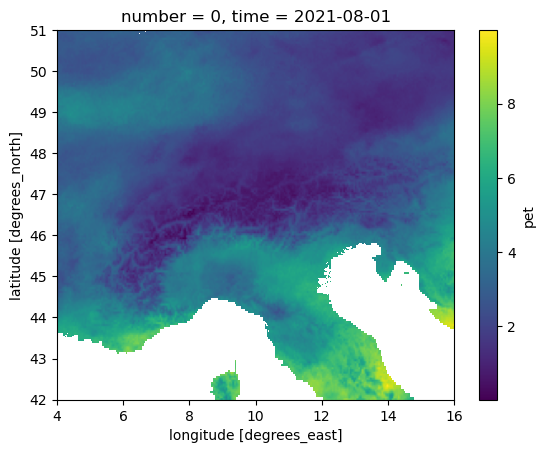

In [7]:
combined_datasets["AUGUST_2021"].pet.isel(number=0).isel(time=0).plot()

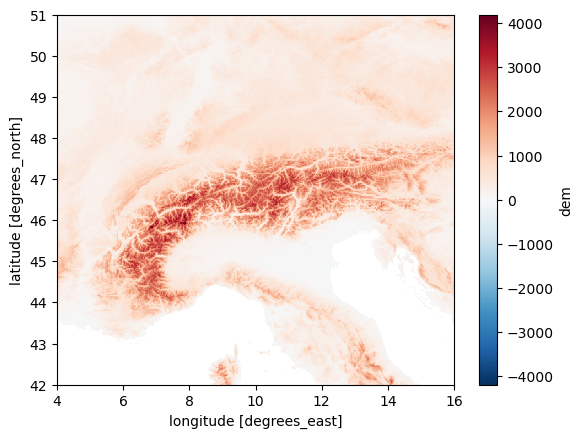

In [17]:
dem.dem.plot()

In [48]:
import xarray as xr
import pyet

# Assuming 'combined_datasets' is a dictionary with keys as 'MONTH_YEAR' and values as Xarray Datasets
for my, ds in combined_datasets.items():
    # Convert temperature from Kelvin to Celsius
    t2m_c = ds['t2m'] - 273.15

    # Convert ssrd from J/m² to MJ/m²
    ssrd_mj = ds['ssrd'] / 1_000_000

    # Extract latitude values; adjust 'y' to match your dataset's latitude coordinate name
    lat = ds['t2m'].coords['y']

    # Compute PET using the Jensen–Haise method
    pet = pyet.jensen_haise(t2m_c, ssrd_mj, lat=lat)

    # Assign the computed PET to the dataset
    ds['pet'] = pet


In [49]:
combined_datasets['APRIL_2022']

<xarray.Dataset> Size: 15GB
Dimensions:  (number: 51, time: 216, y: 180, x: 240)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-04-01 2022-04-02 ... 2022-11-02
  * x        (x) float64 2kB 4.008 4.058 4.109 4.159 ... 15.84 15.89 15.94 15.99
  * y        (y) float64 1kB 42.01 42.06 42.11 42.16 ... 50.84 50.89 50.94 50.99
Data variables:
    t2m      (time, number, y, x) float64 4GB dask.array<chunksize=(27, 7, 45, 60), meta=np.ndarray>
    tp       (time, number, y, x) float64 4GB dask.array<chunksize=(27, 7, 45, 60), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 4GB dask.array<chunksize=(27, 7, 45, 60), meta=np.ndarray>
    pet      (time, number, y, x) float64 4GB dask.array<chunksize=(27, 7, 45, 60), meta=np.ndarray>

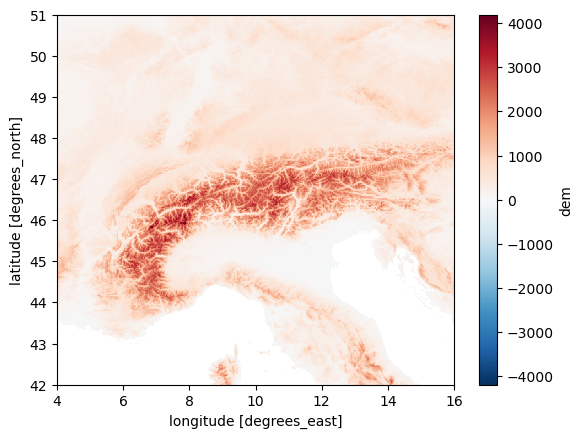

In [27]:
dem.dem.plot()

<xarray.Dataset> Size: 3MB
Dimensions:        (y: 540, x: 720)
Coordinates:
  * y              (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.96 50.97 50.99
  * x              (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.96 15.98 15.99
Data variables:
    land_sea_mask  (y, x) int64 3MB dask.array<chunksize=(135, 421), meta=np.ndarray>

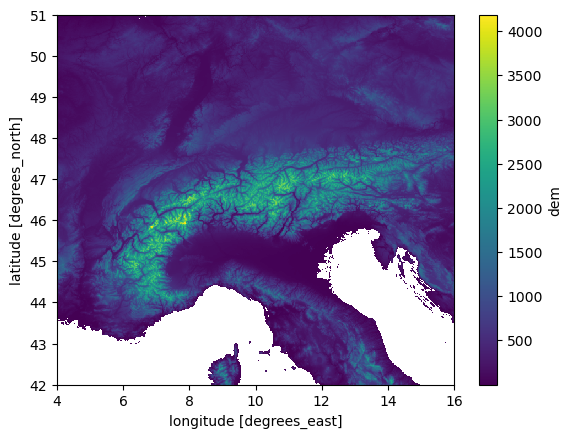

In [29]:
dem_cleaned.dem.plot()

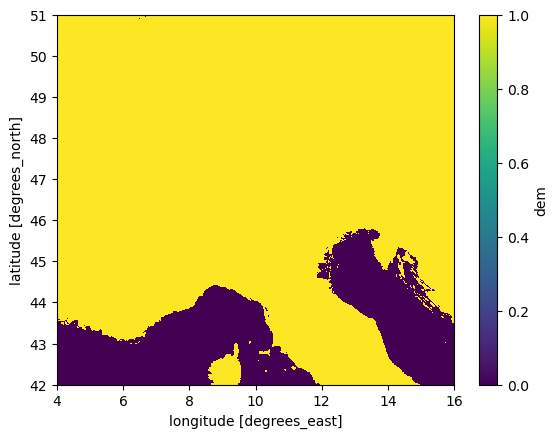

In [32]:
land_sea_mask.dem.plot()

In [53]:
for my, ds in combined_datasets.items():
    # 1. Interpolate to DEM grid
    ds_interp = ds.interp_like(dem)

    # 2. Expand land_sea_mask (shape: [y, x]) to match [time, number, y, x]
    time_dim = ds_interp.sizes["time"]
    number_dim = ds_interp.sizes["number"]
    mask_4d = land_sea_mask.expand_dims(
        {"time": time_dim, "number": number_dim}
    ).transpose("time", "number", "y", "x")

    # 3. Ensure coords match exactly (VERY important)
    for coord in ["x", "y"]:
        mask_4d[coord] = ds_interp[coord]

    # 4. Apply the mask
    ds_masked = ds_interp.where(mask_4d == 1)

    # 5. Debug (optional)
    print(f"{my} - variables after masking: {list(ds_masked.data_vars)}")

    # 6. Save back
    combined_datasets[my] = ds_masked


APRIL_2022 - variables after masking: []
AUGUST_2021 - variables after masking: []
DECEMBER_2021 - variables after masking: []
FEBRUARY_2022 - variables after masking: []
JANUARY_2022 - variables after masking: []
JULY_2022 - variables after masking: []
JUNE_2022 - variables after masking: []
MARCH_2022 - variables after masking: []
MAY_2022 - variables after masking: []
NOVEMBER_2021 - variables after masking: []
OCTOBER_2021 - variables after masking: []
SEPTEMBER_2021 - variables after masking: []


In [71]:
df = combined_datasets['AUGUST_2021'].interp_like(dem)



In [72]:
time_dim = df.sizes["time"]
number_dim = df.sizes["number"]
mask_4d = land_sea_mask.expand_dims(
    {"time": time_dim, "number": number_dim}
).transpose("time", "number", "y", "x")
mask_4d = mask_4d.assign_coords(time=df.time, number=df.number)
mask_4d

<xarray.Dataset> Size: 34GB
Dimensions:        (time: 216, number: 51, y: 540, x: 720)
Coordinates:
  * y              (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.96 50.97 50.99
  * x              (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.96 15.98 15.99
  * time           (time) datetime64[ns] 2kB 2021-08-01 ... 2022-03-04
  * number         (number) int32 204B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
Data variables:
    land_sea_mask  (time, number, y, x) int64 34GB 0 0 0 0 0 0 0 ... 1 1 1 1 1 1

In [61]:
mask_4d

<xarray.Dataset> Size: 34GB
Dimensions:        (time: 216, number: 51, y: 540, x: 720)
Coordinates:
  * y              (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.96 50.97 50.99
  * x              (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.96 15.98 15.99
Dimensions without coordinates: time, number
Data variables:
    land_sea_mask  (time, number, y, x) int64 34GB dask.array<chunksize=(216, 51, 135, 421), meta=np.ndarray>

In [73]:
ds_masked = df.where(mask_4d == 1)

In [74]:
ds_masked

<xarray.Dataset> Size: 12kB
Dimensions:  (number: 51, time: 216, y: 540, x: 720)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.97 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99
Data variables:
    *empty*

In [75]:
df

<xarray.Dataset> Size: 137GB
Dimensions:  (number: 51, time: 216, y: 540, x: 720)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.97 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99
Data variables:
    t2m      (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    tp       (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    pet      (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>

In [77]:
# 2. Use nearest-neighbor for mask alignment
mask_aligned = land_sea_mask.reindex_like(df, method='nearest')

# 3. Apply mask with fill value for debugging
ds_masked = df.where(mask_aligned == 1)

# 4. Check if any data remains
for var in ds_masked.data_vars:
    print(f"{my} {var}: {ds_masked[var].notnull().sum().item()} valid points")

In [78]:
ds_masked

<xarray.Dataset> Size: 12kB
Dimensions:  (number: 51, time: 216, y: 540, x: 720)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.97 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99
Data variables:
    *empty*

In [16]:
# Assume:
# - ds is your 4D xarray.Dataset with dims (time, number, x, y)
# - land_sea_mask is a 2D xarray.DataArray with dims (x, y), where 1 = land, 0 = sea
df = combined_datasets["APRIL_2022"]
# 1. Expand land-sea mask to 4D
mask_4d = land_sea_mask.expand_dims(
    {"time": df.sizes["time"], "number": df.sizes["number"]}
).transpose("time", "number", "x", "y")

# 2. Apply the mask (keep land, mask sea)
ds_clipped = df.where(mask_4d == 1)
ds_clipped.compute()

<xarray.Dataset> Size: 2kB
Dimensions:  (number: 51, time: 216, x: 2, y: 2)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-04-01 2022-04-02 ... 2022-11-02
  * x        (x) float64 16B 4.008 15.99
  * y        (y) float64 16B 42.01 50.99
Data variables:
    *empty*

In [30]:
import xarray as xr

def same_grid(ds1, ds2):
    # Check if dimensions are the same
    if set(ds1.y.values) != set(ds2.y.values) and set(ds1.x.values) != set(ds2.x.values):
        return False

    if set(ds1.y.values) == set(ds2.y.values) and set(ds1.x.values) == set(ds2.x.values):
        return True

# Example usage:
# ds1 = xr.open_dataset('file1.nc')
# ds2 = xr.open_dataset('file2.nc')
print(same_grid(combined_datasets["APRIL_2022"], land_sea_mask))  # True if grids are identical, False otherwise

True


In [28]:
combined_datasets["APRIL_2022"]

<xarray.Dataset> Size: 137GB
Dimensions:  (number: 51, time: 216, y: 540, x: 720)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-04-01 2022-04-02 ... 2022-11-02
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.97 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99
Data variables:
    t2m      (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    tp       (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>
    pet      (time, number, y, x) float64 34GB dask.array<chunksize=(27, 7, 540, 720), meta=np.ndarray>

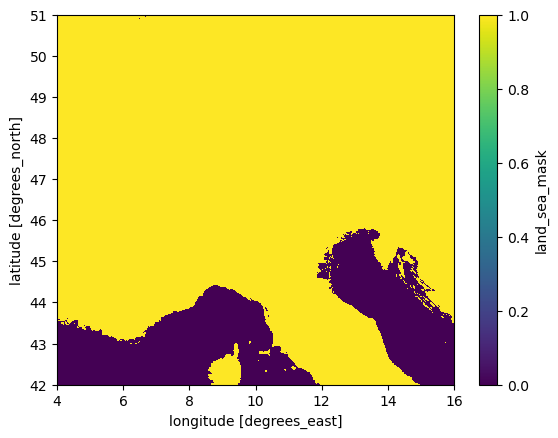

In [31]:
land_sea_mask.land_sea_mask.plot()

In [ ]:
import xarray as xr

def apply_land_sea_mask(main_ds, mask_ds, land_value=1, sea_value=0):
    """
    Apply land-sea mask to a dataset, masking out either land or sea areas.
    
    Parameters:
    - main_ds: xarray Dataset with dimensions (x, y, number, time)
    - mask_ds: xarray Dataset with dimensions (x, y) containing mask values
    - land_value: value in mask that represents land (will be masked)
    - sea_value: value in mask that represents sea (will be kept)
    
    Returns:
    - Masked xarray Dataset
    """
    # Ensure the mask is aligned with the main dataset
    mask_aligned = mask_ds.reindex_like(main_ds, method='nearest')
    
    # Create a boolean mask where sea areas are True
    sea_mask = (mask_aligned == sea_value)
    
    # Apply the mask to all variables in the dataset
    masked_ds = main_ds.where(sea_mask)
    
    return masked_ds

# Usage example:
# masked_ds = apply_land_sea_mask(ds, land_sea_mask)

In [ ]:
# Save to Zarr
zarr_path = f"/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_{month}.zarr"

# Loop through each variable and save it one by one
for i, var_name in enumerate(SEAS5_interpolated.data_vars):
    print(f"  Saving variable {i+1}/{len(SEAS5_interpolated.data_vars)}: {var_name}")
    
    # Select only the current variable
    var_ds = SEAS5_interpolated[[var_name]]
    
    # Write to Zarr (use 'w' mode for the first variable, 'a' for subsequent ones)
    mode = "w" if i == 0 else "a"
    var_ds.to_zarr(zarr_path, mode=mode, compute=True)

print(f"Completed processing {month}")

/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_{month}.zarr

In [4]:
# Define output directory
output_dir = Path("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/")

# Define units for each variable
variable_units = {
    't2m': 'K',                # Temperature at 2m (converted from Kelvin)
    'tp': 'mm/day',             # Total precipitation
    'ssrd': 'J/m²/day',        # Surface solar radiation
    'pet': 'mm/day'             # Potential evapotranspiration
}

# Define units for each variable
variable_names = {
    't2m': 'daily mean 2m_temperature',                # Temperature at 2m (converted from Kelvin)
    'tp': 'daily accumulated total precipitation',             # Total precipitation
    'ssrd': 'daily accumulated surface solar radiation downward',        # Surface solar radiation
    'pet': 'potential evapotranspiration calculated using jensen haise method using pyet package'             # Potential evapotranspiration
}


# Process and save each month-year dataset
for my, ds in combined_datasets.items():
    print(f"Processing {my}...")
    
    # Create output path for this month-year
    zarr_path = output_dir / f"SEAS5_downscaled_{my}.zarr"
    
    # Save to Zarr (one variable at a time to handle large datasets)
    for i, var_name in enumerate(ds.data_vars):
        print(f"  Saving variable {i+1}/{len(ds.data_vars)}: {var_name}")
        
        # Select only the current variable
        var_ds = ds[[var_name]]
        var_ds[var_name].attrs['units'] = variable_units[var_name]
        var_ds[var_name].attrs['long_name'] = variable_names[var_name]
        
        # Write to Zarr (use 'w' mode for first variable, 'a' for subsequent)
        mode = "w" if i == 0 else "a"
        var_ds.to_zarr(zarr_path, mode=mode, compute=True)
    
    print(f"Completed processing and saving {my}\n")

Processing APRIL_2022...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/4: ssrd
  Saving variable 4/4: pet
Completed processing and saving APRIL_2022

Processing AUGUST_2021...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/4: ssrd
  Saving variable 4/4: pet
Completed processing and saving AUGUST_2021

Processing DECEMBER_2021...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/4: ssrd
  Saving variable 4/4: pet
Completed processing and saving DECEMBER_2021

Processing FEBRUARY_2022...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/4: ssrd
  Saving variable 4/4: pet
Completed processing and saving FEBRUARY_2022

Processing JANUARY_2022...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/4: ssrd
  Saving variable 4/4: pet
Completed processing and saving JANUARY_2022

Processing JULY_2022...
  Saving variable 1/4: t2m
  Saving variable 2/4: tp
  Saving variable 3/

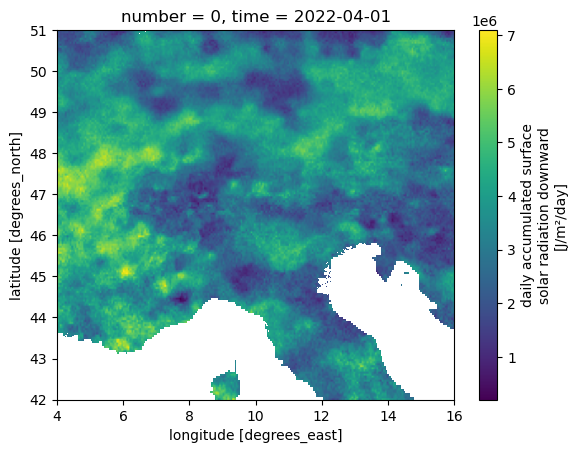

In [41]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/SEAS5_downscaled_APRIL_2022.zarr")
ds.ssrd.isel(number=0).isel(time=0).plot()

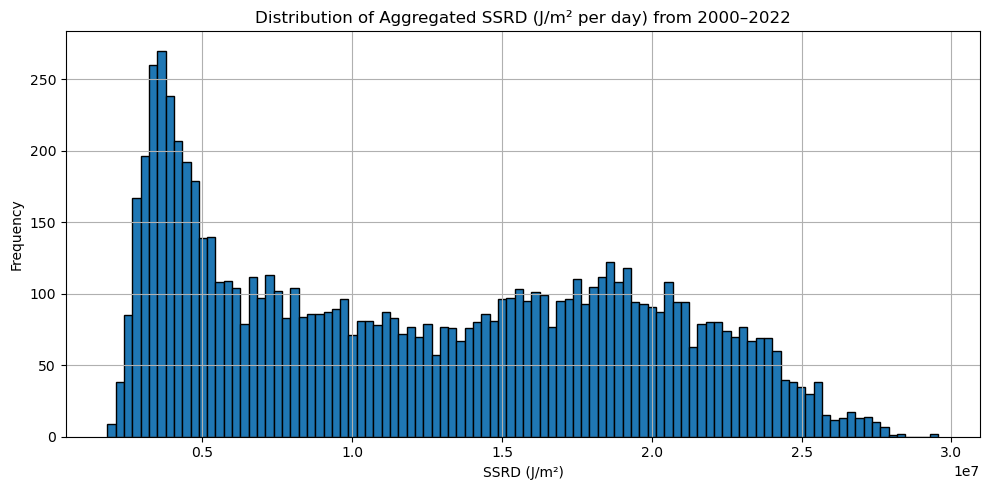

In [48]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/data/EMO1_PROCESSED_2000_2022_ta24_pr_rg_pet_daily.zarr/")
ds = ds.rename({"ta24": "t2m", "pr": "tp", "rg": "ssrd"})
ds["t2m"] = ds["t2m"] + 273.15
ds = ds.sortby("lat")

# Aggregate ssrd over spatial dimensions
ssrd_agg = ds["ssrd"].mean(dim=["lat", "lon"], skipna=True)

# Plot the distribution
plt.figure(figsize=(10, 5))
ssrd_agg.plot.hist(bins=100, edgecolor='black')
plt.title("Distribution of Aggregated SSRD (J/m² per day) from 2000–2022")
plt.xlabel("SSRD (J/m²)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()




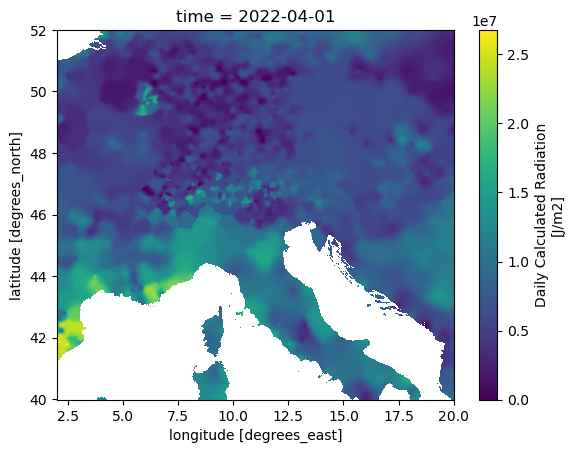

In [44]:
ds.ssrd.sel(time="2022-04-01").plot()

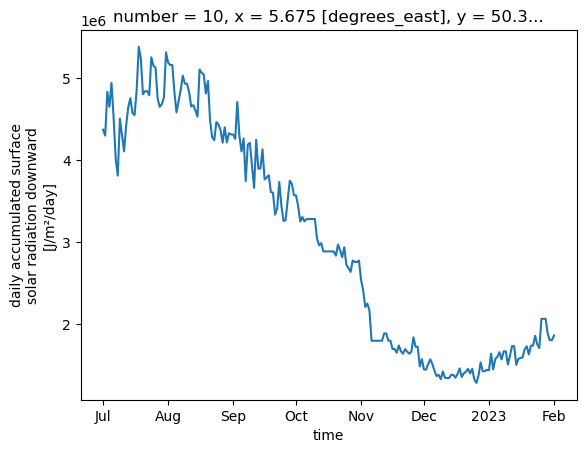

In [47]:
ds = xr.open_dataset("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/SEAS5_downscaled_JULY_2022.zarr/", engine="zarr")
ds.ssrd.isel(x=100, y=500, number=10).plot()

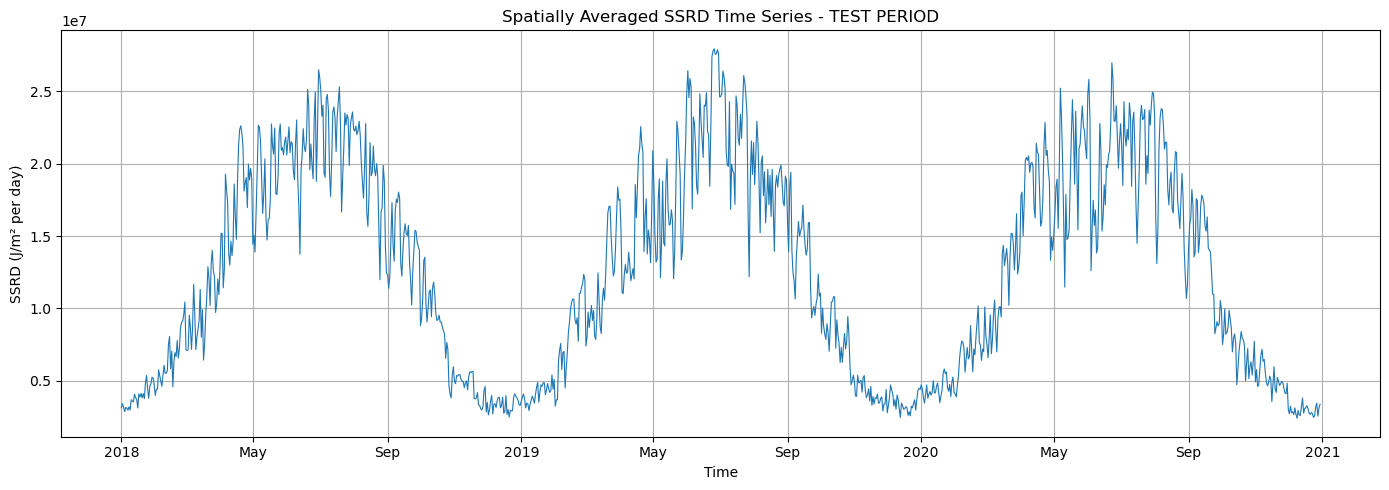

In [57]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/TEST/ssrd_test_predictions_v3.zarr/")

ssrd_spatial_mean = ds["ssrd"].mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

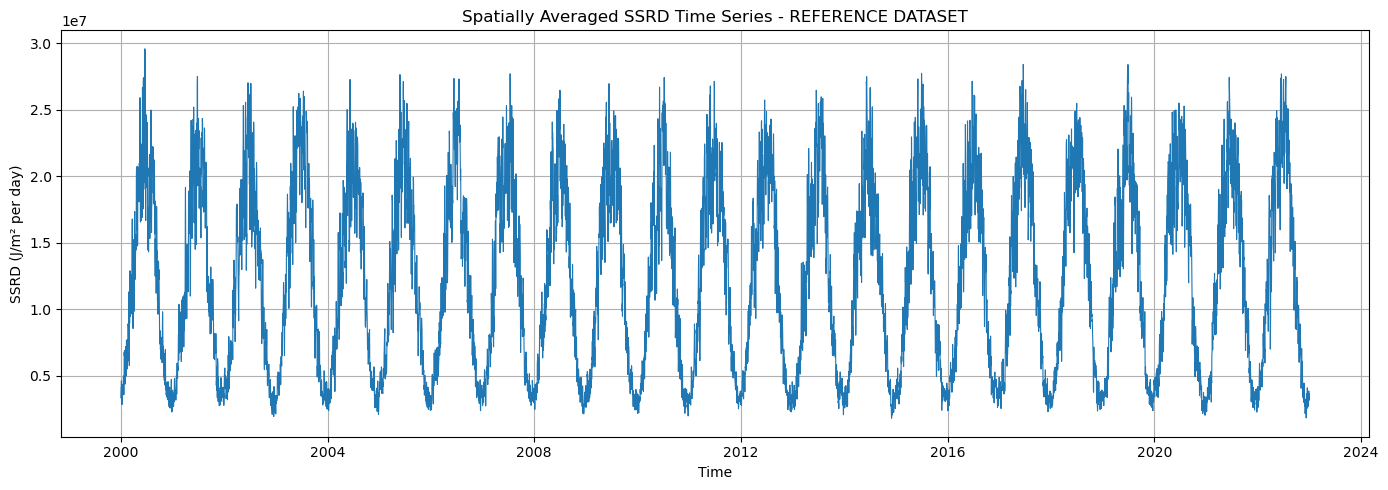

In [58]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/data/EMO1_PROCESSED_2000_2022_ta24_pr_rg_pet_daily.zarr/")
ds = ds.rename({"ta24": "t2m", "pr": "tp", "rg": "ssrd"})
ssrd_spatial_mean = ds["ssrd"].mean(dim=["lat", "lon"], skipna=True)
# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - REFERENCE DATASET")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()


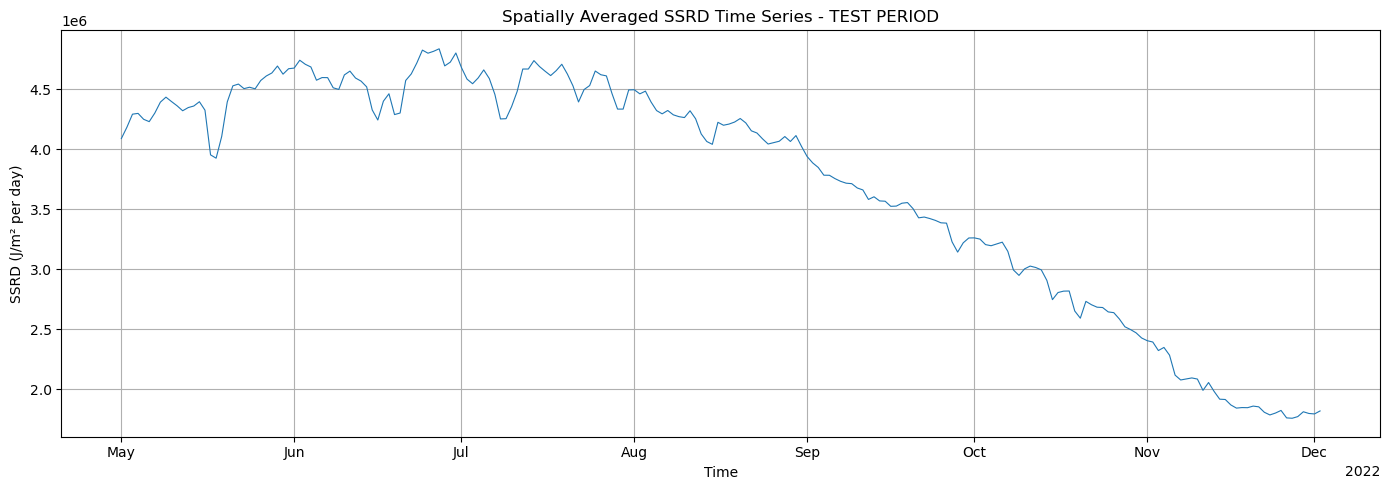

In [60]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/SEAS5_downscaled_MAY_2022.zarr/")

ssrd_spatial_mean = ds["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

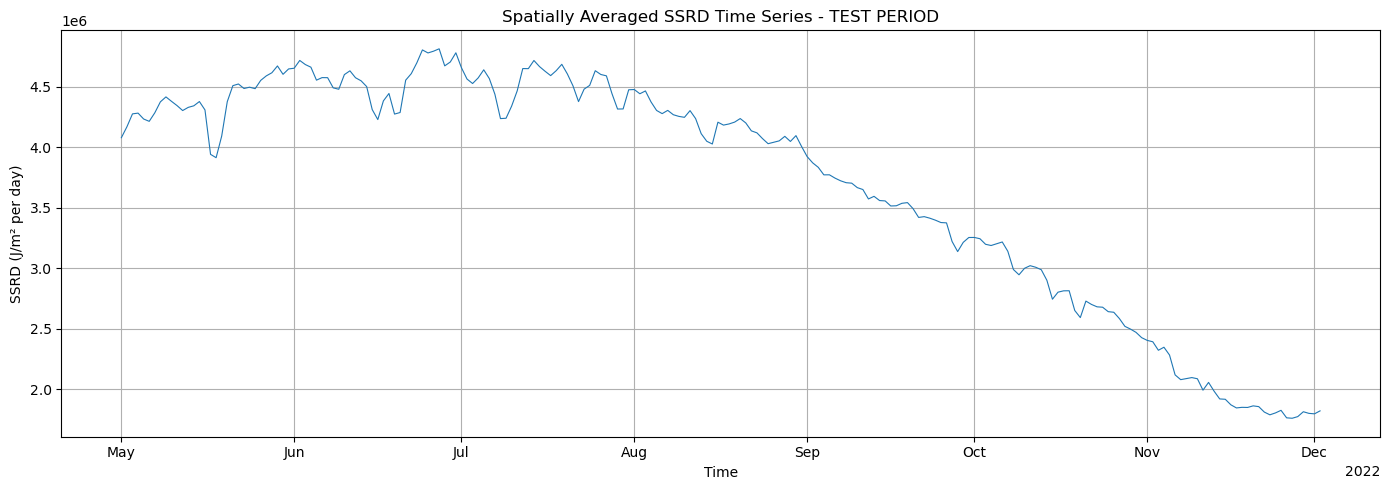

In [62]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ssrd_v3/ssrd_seas5_MAY_2022.zarr")

ssrd_spatial_mean = ds["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

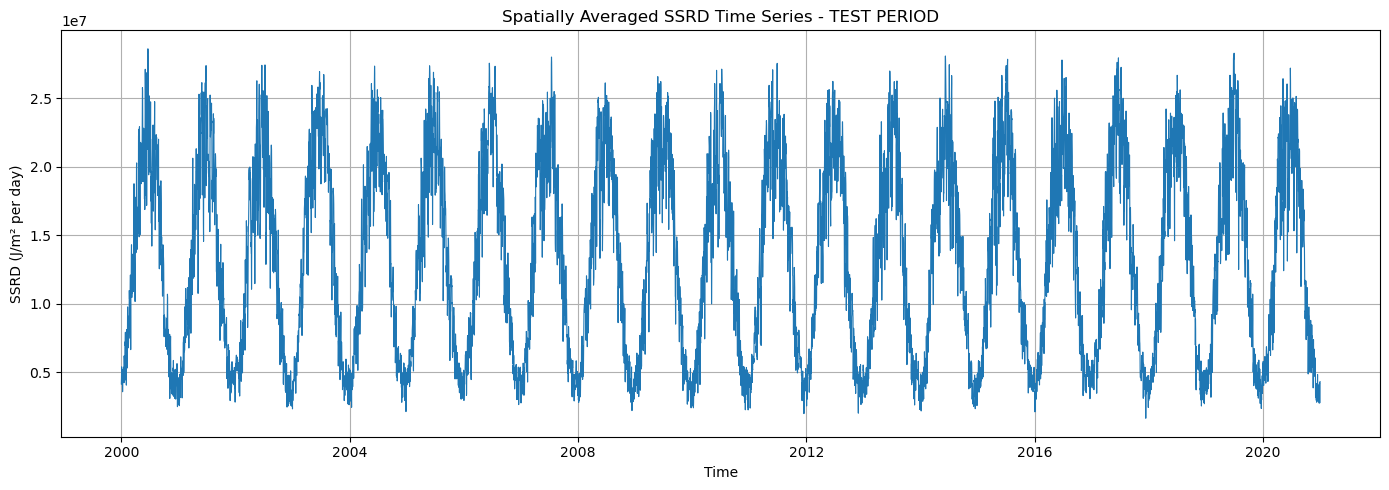

In [64]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ERA5_to_latent_by_3.zarr/")

ssrd_spatial_mean = ds["ssrd"].mean(dim=["lat", "lon"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ERA5_to_latent_by_3.zarr/")

ssrd_spatial_mean = ds["ssrd"].mean(dim=["lat", "lon"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

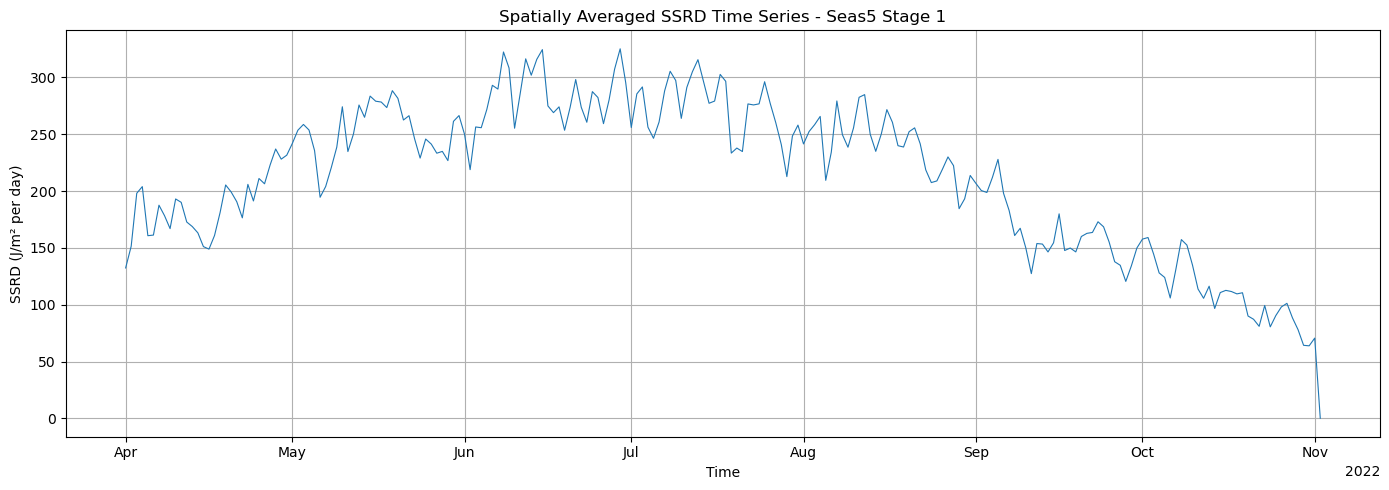

In [75]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/SEAS5_to_latent/SEAS5_to_latent_APRIL_2022.zarr")

ssrd_spatial_mean = ds["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - Seas5 Stage 1")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

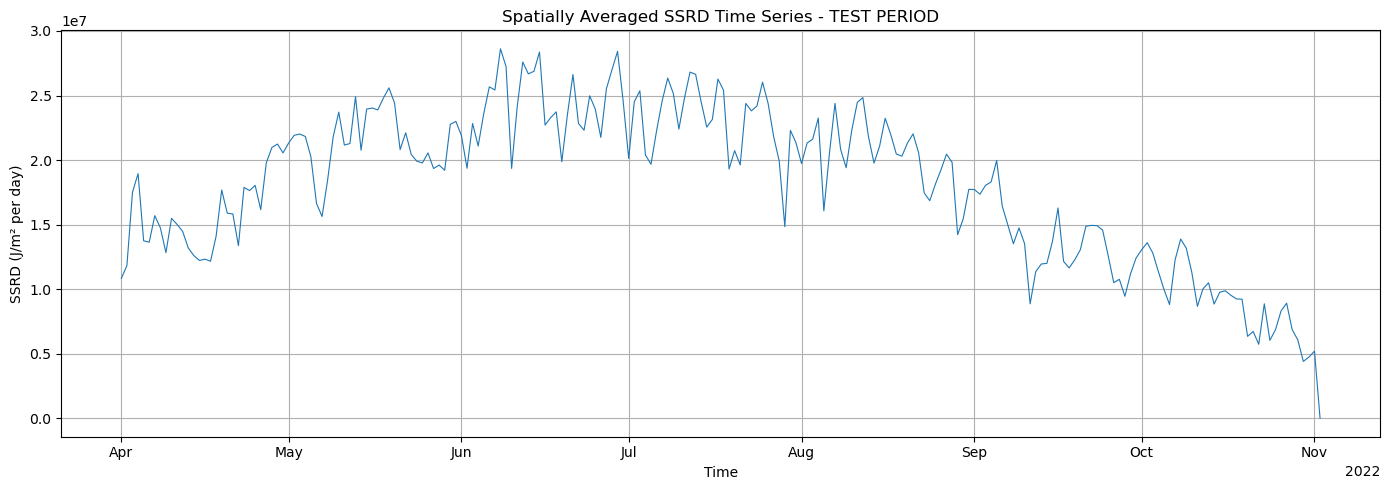

In [72]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = f"https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_APRIL_2022"

# Specify the spatial extent (bounding box)
# Specify the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the data cube with specified parameters
seas5_single = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
).execute().to_dataset(dim='bands')

seas5_single["ssrd"] = seas5_single["ssrd"] * 86400

ssrd_spatial_mean = seas5_single["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

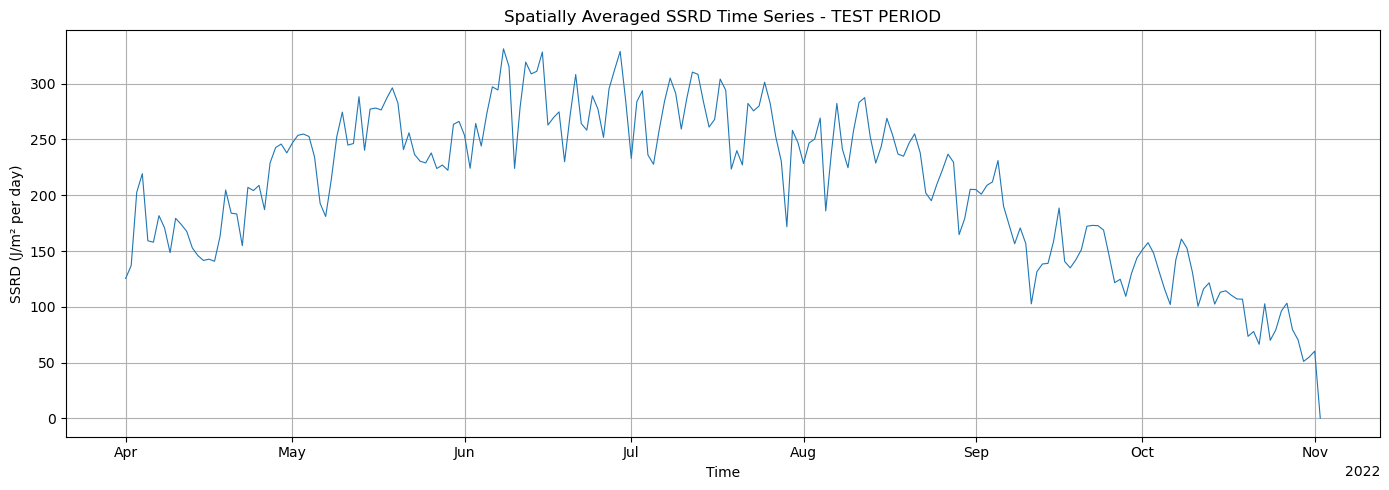

In [71]:
ssrd_spatial_mean = seas5_single["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - TEST PERIOD")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

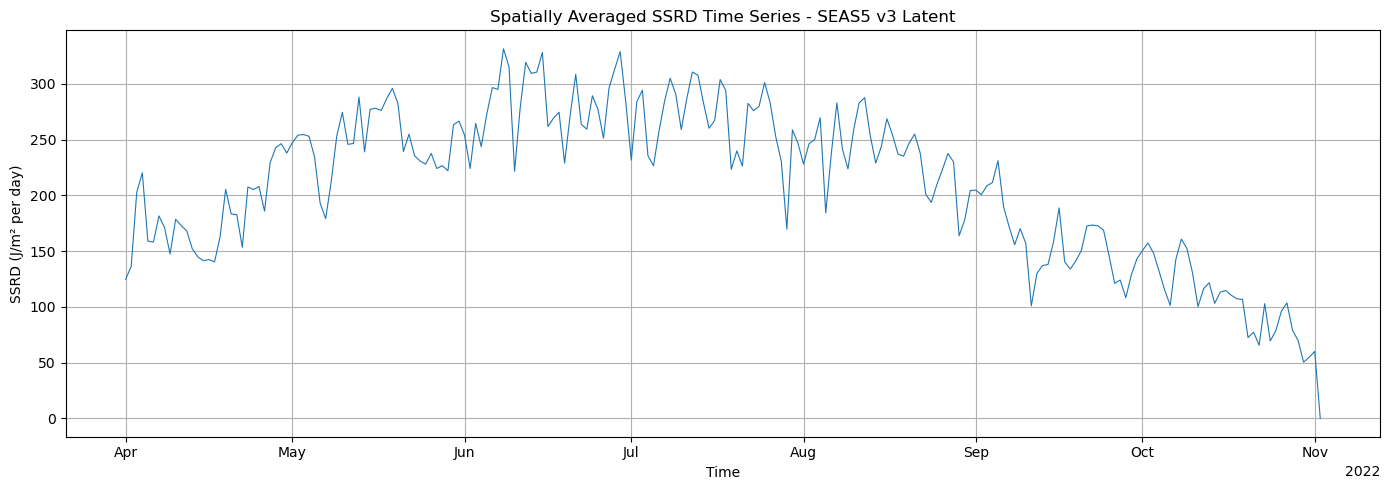

In [73]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_APRIL_2022.zarr/")

ssrd_spatial_mean = ds["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - SEAS5 v3 Latent")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Inspect the Precipitation - Land Sea Mask

In [ ]:
import xarray as xr

In [76]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = "https://stac.intertwin.fedcloud.eu/collections/ERA5_T2M_SSRD_TP"

# Specify the temporal extent
temporal_extent = ["2000-01-01", "2020-12-31"]

# Specify the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the data cube with specified parameters
era5_single = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
).execute().to_dataset(dim='bands')


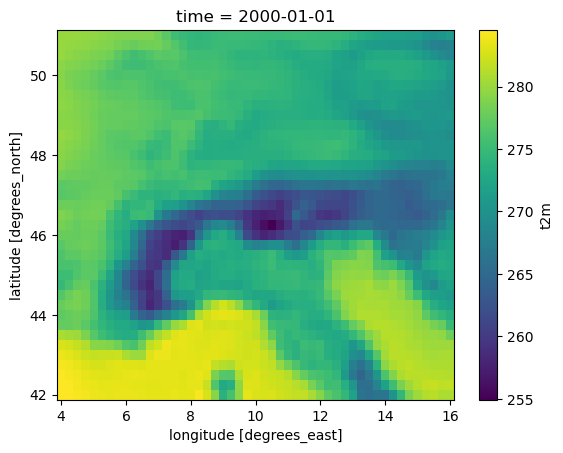

In [80]:
era5_single.t2m.isel(time=0).plot()

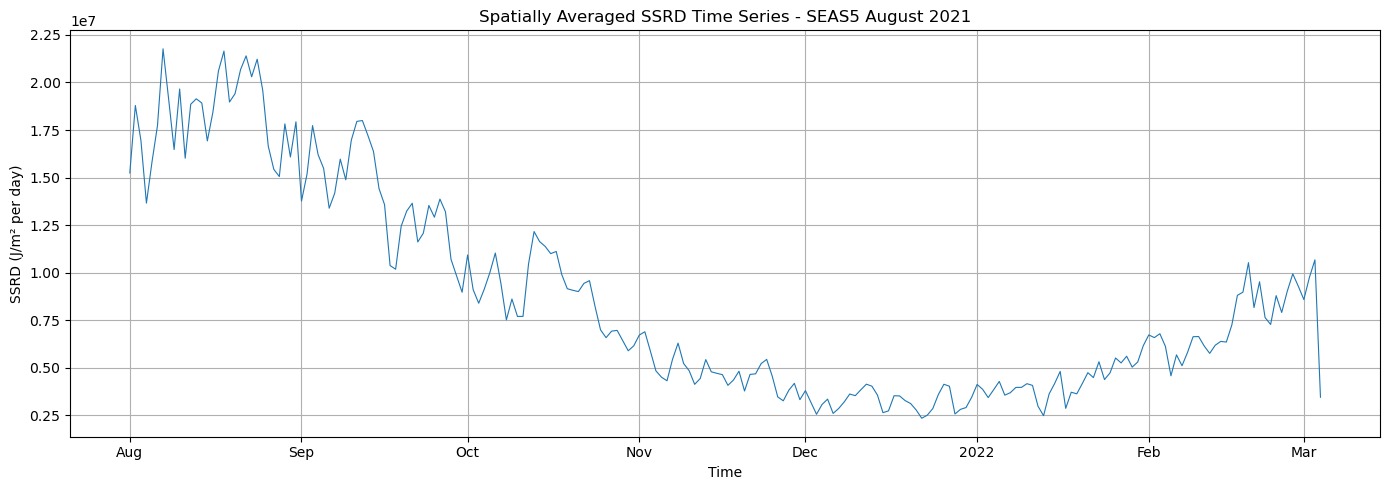

In [81]:
import xarray as xr
import matplotlib.pyplot as plt

# Load and preprocess dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ssrd_seas5_AUGUST_2021.zarr")

ssrd_spatial_mean = ds["ssrd"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged SSRD Time Series - SEAS5 August 2021")
plt.xlabel("Time")
plt.ylabel("SSRD (J/m² per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

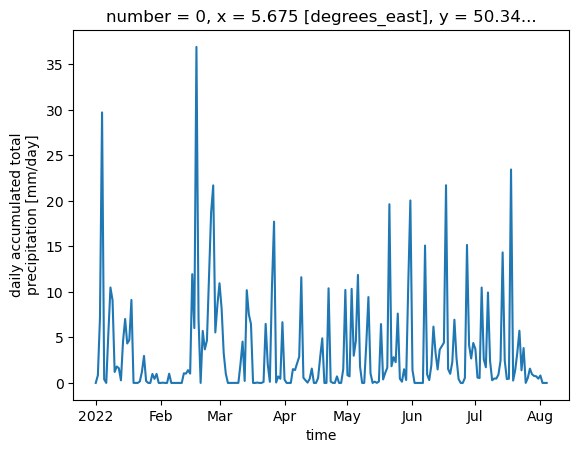

In [2]:
import xarray as xr

ds = xr.open_dataset("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/SEAS5_downscaled_JANUARY_2022.zarr/", engine="zarr")
ds.tp.isel(x=100, y=500, number=0).plot()

In [19]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/data/EMO1_PROCESSED_2000_2022_ta24_pr_rg_pet_daily.zarr/")
ds = ds.sel(lat=slice(51, 42), lon=slice(4, 16))
ds = ds.sel(time=slice("2022-01-01", "2022-09-01"))
ds = ds.sortby("lat")
ds.pr.sel(lon=5.675, lat=50.34).plot()


KeyError: "not all values found in index 'lon'. Try setting the `method` keyword argument (example: method='nearest')."

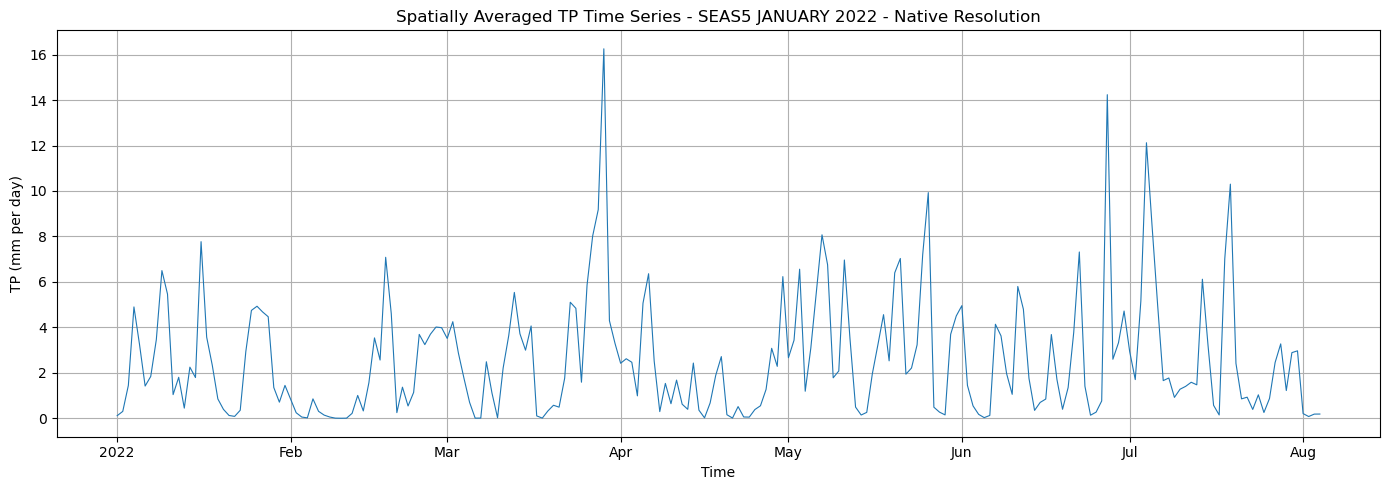

In [21]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_JANUARY_2022.zarr", engine="zarr")
ssrd_spatial_mean = ds["tp"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged TP Time Series - SEAS5 JANUARY 2022 - Native Resolution")
plt.xlabel("Time")
plt.ylabel("TP (mm per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

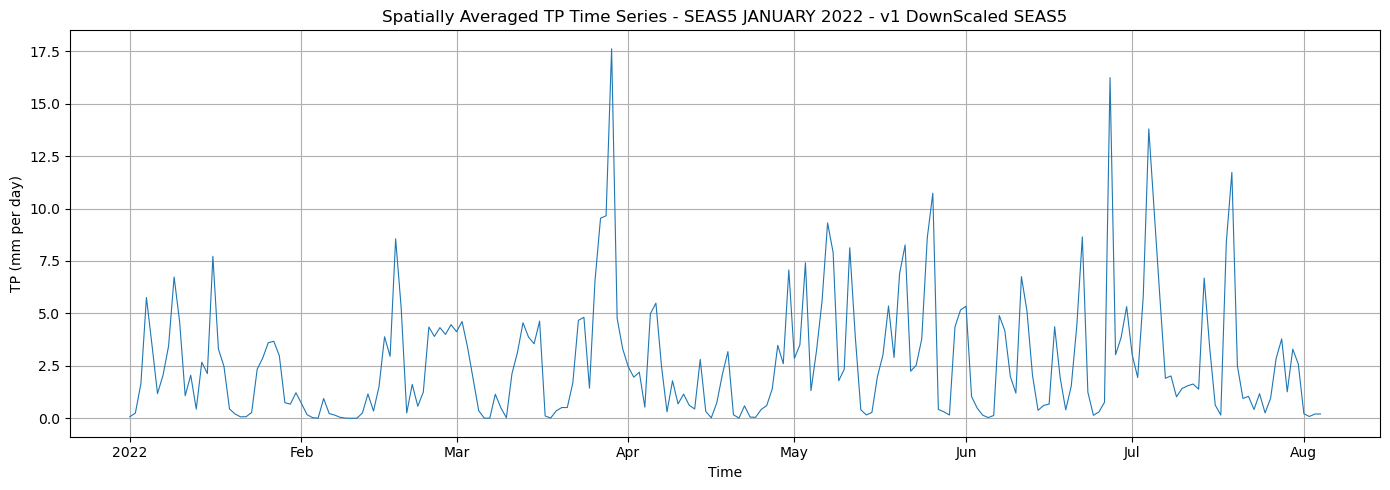

In [23]:
import xarray as xr

ds = xr.open_dataset("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/PAPER/v1/SEAS5/SEAS5_downscaled_JANUARY_2022.zarr/", engine="zarr")
ssrd_spatial_mean = ds["tp"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged TP Time Series - SEAS5 JANUARY 2022 - v1 DownScaled SEAS5")
plt.xlabel("Time")
plt.ylabel("TP (mm per day)")
plt.grid(True)
plt.tight_layout()
plt.show()

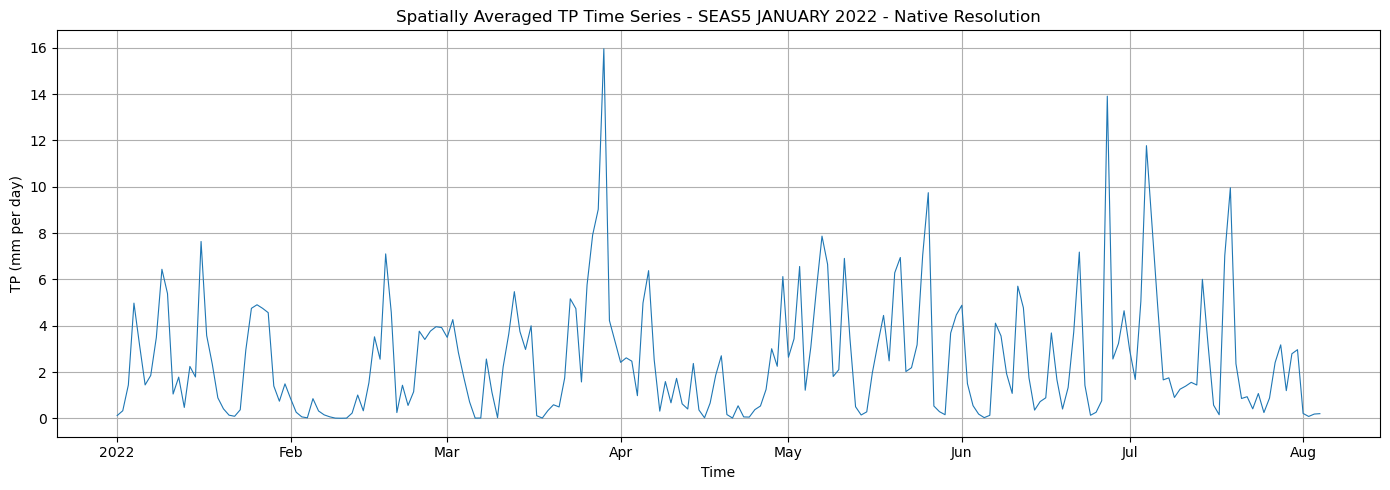

In [25]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = f"https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_JANUARY_2022"

# Specify the spatial extent (bounding box)
# Specify the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the data cube with specified parameters
seas5_single = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
).execute().to_dataset(dim='bands')

ssrd_spatial_mean = seas5_single["tp"].isel(number=0).mean(dim=["y", "x"], skipna=True)

# Plot time series
plt.figure(figsize=(14, 5))
ssrd_spatial_mean.plot(linewidth=0.8)
plt.title("Spatially Averaged TP Time Series - SEAS5 JANUARY 2022 - Native Resolution")
plt.xlabel("Time")
plt.ylabel("TP (mm per day)")
plt.grid(True)
plt.tight_layout()
plt.show()